TASK 1: Data Understanding

In [1]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


TASK 2: Data Cleaning

In [3]:
import numpy as np

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

/var/folders/8n/j8wgm5f924s41_y6d7k5wf_00000gn/T/ipykernel_10436/676340666.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
/var/folders/8n/j8wgm5f924s41_y6d7k5wf_00000gn/T/ipykernel_10436/676340666.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series 

In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

TASK 3: EDA (Visualization)

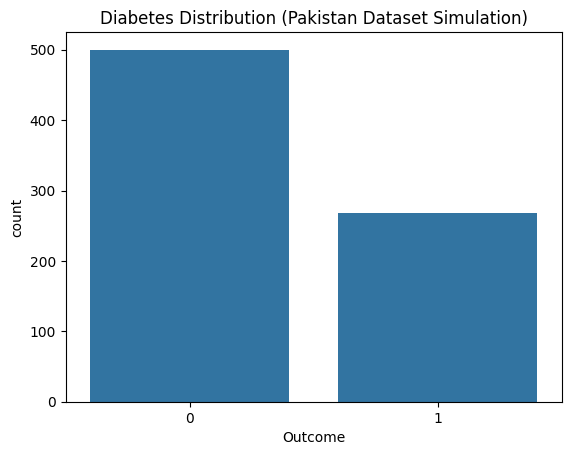

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution (Pakistan Dataset Simulation)")
plt.show()

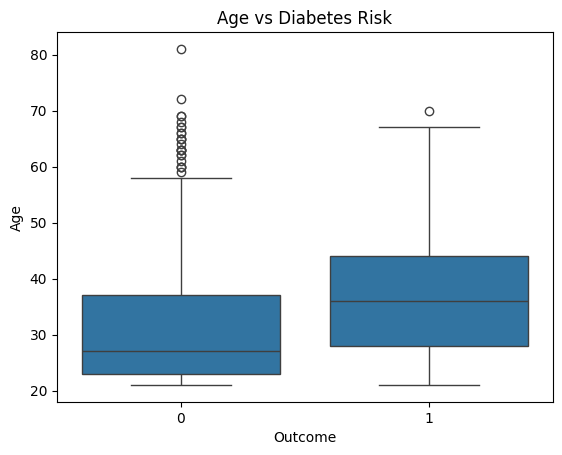

In [6]:
sns.boxplot(x="Outcome", y="Age", data=df)
plt.title("Age vs Diabetes Risk")
plt.show()

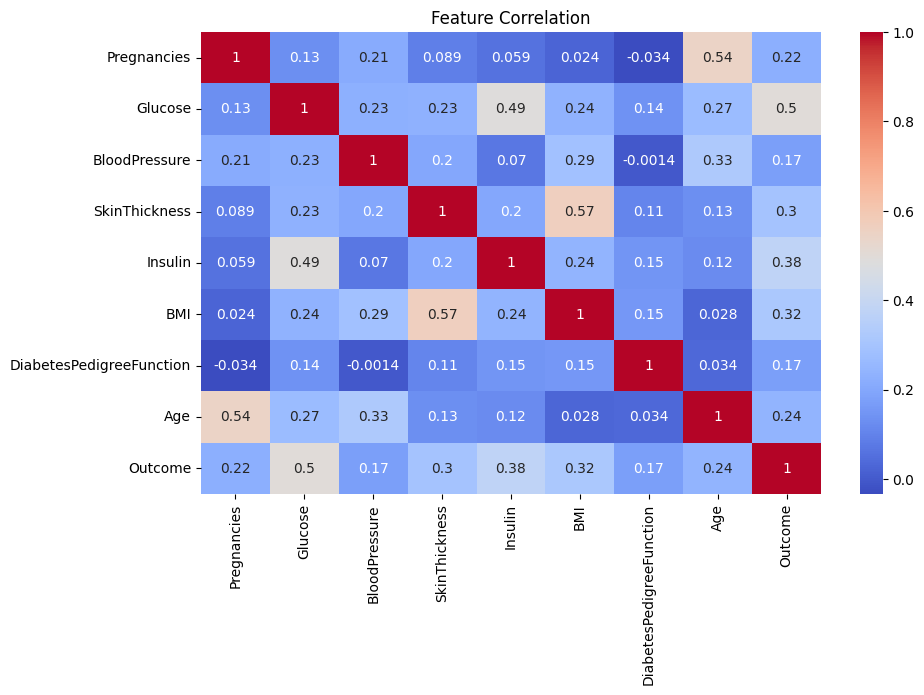

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

TASK 4: Machine Learning Model

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7727272727272727


In [11]:
print("Model expects these features:")
print(X.columns)

Model expects these features:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')


In [12]:
sample = [[
    2,      # Pregnancies
    120,    # Glucose
    70,     # BloodPressure
    20,     # SkinThickness
    85,     # Insulin
    32.5,   # BMI
    0.5,    # DiabetesPedigreeFunction (important missing value)
    30      # Age
]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Patient likely has Diabetes")
else:
    print("Patient is healthy")

Patient is healthy


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [14]:
y_pred = model.predict(X_test)

In [15]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[83 16]
 [19 36]]


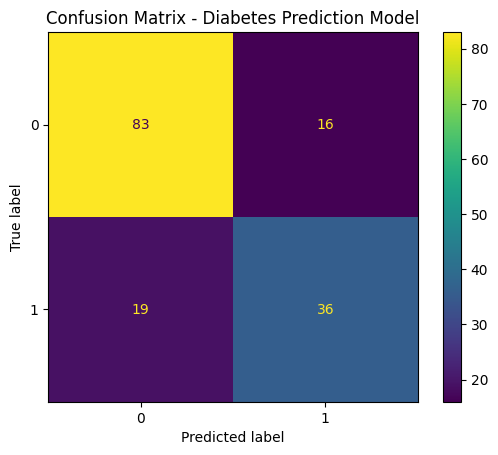

In [16]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Diabetes Prediction Model")
plt.show()

In [1]:
pip install streamlit


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Overall, this project demonstrates a complete end-to-end data science workflow for predicting diabetes using machine learning, starting from data collection and understanding to data cleaning, exploratory data analysis, model building, and evaluation. The dataset was carefully preprocessed by handling missing and invalid values, followed by statistical analysis and visualizations to identify important patterns and relationships among medical features. A Logistic Regression model was trained to predict the likelihood of diabetes, and its performance was evaluated using accuracy and a confusion matrix to ensure reliable results, especially in a healthcare context where incorrect predictions can have serious consequences. Finally, an interactive Streamlit dashboard was developed to make the system user-friendly, allowing real-time predictions based on patient inputs. This project highlights how data science and machine learning can be effectively applied in the healthcare sector, particularly for early diabetes risk detection, which can be highly beneficial in countries like Pakistan where early diagnosis and awareness are critical for improving public health outcomes.

A Streamlit dashboard was developed to simulate a real-world healthcare system where users can input patient data and receive instant diabetes risk predictions.